In [1]:
import oqupy
import oqupy.operators as op
import scipy.integrate as spi
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':0.2} #0.25

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
# dt = 1./omega_cutoff/np.sqrt(3)
dt=pt_parameters['dt']

tcut=27

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [2]:

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=500)

In [3]:
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD_analytical(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [4]:
# converged parameters for different protocol times 
protocol_times=[200]

pt_var=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_var = pt_var.get_process_tensor()

pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
process_tensor_varcf = pt_varcf.get_process_tensor()


building influence functional:   0%|          | 0/500 [00:00<?, ?it/s]/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:59: RuntimeWarning: divide by zero encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:59: RuntimeWarning: overflow encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:59: RuntimeWarning: invalid value encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:60: RuntimeWarning: divide by zero encountered in matmul
  B = (v @ np.diag(1 / sBA)).reshape(rank_new, d2, rank_BA)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:60: RuntimeWarning: overflow encountered in matmul
  B = (v @ np.diag(1 / sBA)).reshape(rank_new, d2, rank_BA)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:60: Run

rank  39


building influence functional:   0%|          | 0/500 [00:00<?, ?it/s]/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useheatmarkers.py:59: RuntimeWarning: divide by zero encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useheatmarkers.py:59: RuntimeWarning: overflow encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useheatmarkers.py:59: RuntimeWarning: invalid value encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useheatmarkers.py:60: RuntimeWarning: divide by zero encountered in matmul
  B = (v @ np.diag(1 / sBA)).reshape(rank_new, d2, rank_BA)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useheatmarkers.py:60: RuntimeWarning: overflow encountered in matmul
  B = (v @ np.diag(1 / sBA)).reshape(rank_new, d2, rank_BA)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useheatmarker

rank  39


In [6]:
def hamiltonian_t(t):
      return pt_parameters['omega_cutoff']*op.sigma('x')/2 #*t/2 *(1/1)
u=0.01
ss_rho=process_tensor_var._tebd.steadystate(hamiltonian_t(1))
print(ss_rho)
print(np.trace(ss_rho@op.sigma('x')))
print(np.array([process_tensor_varcf._tebd.steadystate(hamiltonian_t(1))]).trace(axis1=1,axis2=2).imag/u)


[[ 0.5       +1.29905284e-14j -0.48641673-8.16447308e-14j]
 [-0.48641673-1.02387249e-13j  0.5       -1.29631607e-14j]]
(-0.9728334528794671-1.840319795772887e-13j)
[4.10472705e-16]


In [7]:
# comparison to polaron result
poldp=spi.quad(lambda x: correlations.spectral_density(x)/(4.0*(x**2+1.0)),0,30)[0] # heat transferred in polaron
polpred=-np.exp(-2*poldp)
print(polpred)

-0.9662450556387991


In [ ]:
splitting=1.0
r1li=[]
r2li=[]
alphalist=[0.01,0.05,0.1,0.15,0.2]
for alpha in alphalist:
    ham=splitting*op.sigma('x')/2
    correlations = oqupy.PowerLawSD(alpha=alpha,
                                    zeta=1,
                                    cutoff=omega_cutoff,
                                    cutoff_type='exponential',
                                    temperature=temperature)
    bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
    parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=500)
    pt_var=TTITempo(bath,start_time=0.0,parameters=parameters)
    process_tensor_var = pt_var.get_process_tensor()
    ss_rho=process_tensor_var._tebd.steadystate(ham)
    sigx=np.trace(ss_rho@op.sigma('x'))
    poldp=spi.quad(lambda x: correlations.spectral_density(x)/(4.0*(x**2+splitting**2)),0,30)[0] # heat transferred in polaron
    polpred=-np.exp(-2*poldp)
    r1li.append(sigx)
    r2li.append(polpred)



building influence functional:   0%|          | 0/500 [00:00<?, ?it/s]/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:59: RuntimeWarning: divide by zero encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:59: RuntimeWarning: overflow encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:59: RuntimeWarning: invalid value encountered in matmul
  A = (np.diag(1 / sBA) @ u).reshape(sBA.shape[0], d1, rank_new)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:60: RuntimeWarning: divide by zero encountered in matmul
  B = (v @ np.diag(1 / sBA)).reshape(rank_new, d2, rank_BA)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:60: RuntimeWarning: overflow encountered in matmul
  B = (v @ np.diag(1 / sBA)).reshape(rank_new, d2, rank_BA)
/Users/easthamp/OPOld/oqupy/iTEBD_TEMPO_useoqupybath.py:60: Run

rank  12


building influence functional: 100%|██████████| 500/500 [00:00<00:00, 8302.63it/s]


rank  26


building influence functional: 100%|██████████| 500/500 [00:00<00:00, 7447.01it/s]


...

building influence functional: 100%|██████████| 500/500 [00:00<00:00, 6786.66it/s]


rank  49


building influence functional:   0%|          | 0/500 [00:00<?, ?it/s]

building influence functional: 100%|██████████| 500/500 [00:00<00:00, 4723.40it/s]


rank  66


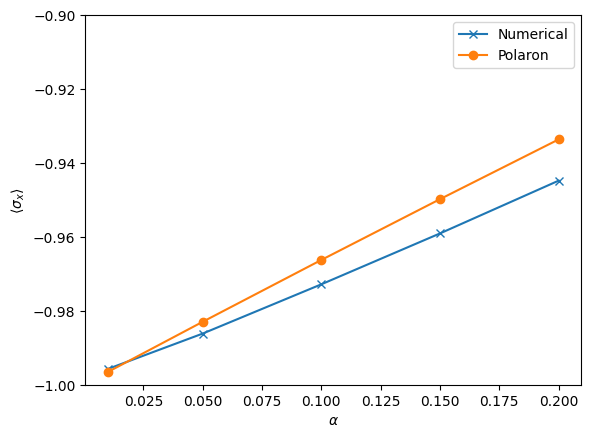

In [27]:
fig,ax=plt.subplots(1)
ax.plot(alphalist,r1li,'x-',label='Numerical')
ax.plot(alphalist,r2li,'o-',label='Polaron')
ax.set_ylim(-1.0,-0.9)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\langle\sigma_x\rangle$')
ax.legend()

In [ ]:
plt.plot()

In [11]:
r2li

[-0.9965721090635934,
 -0.9829776475784173,
 -0.9662450556387991,
 -0.9497972917761037,
 -0.933629507546426]

--> Compute dynamics:
100.0% 10000 of 10000 [########################################] 00:00:36
Elapsed time: 36.7s
--> Compute dynamics:
100.0% 10000 of 10000 [########################################] 00:00:38
Elapsed time: 38.6s


/var/folders/7j/h_f__xy953v4yjm9p8nw1gn80000gn/T/ipykernel_38434/1639565641.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


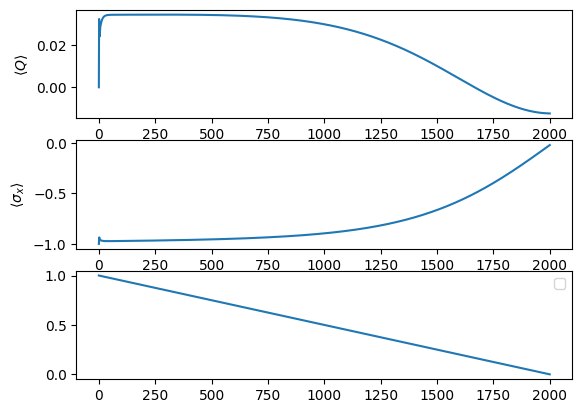

In [ ]:
inisplit=1.0
# choose initial state to be thermal equilibrium given hamiltonian inisplit*(sigmax/2)
z=2*np.cosh(inisplit/(2*temperature))
pupx=np.exp(-inisplit/(2*temperature))/z
pdnx=np.exp(+inisplit/(2*temperature))/z

rhoini=oqupy.operators.spin_dm('x+')*pupx+oqupy.operators.spin_dm('x-')*pdnx

for t_prot in [2000]:

   fig,axs=plt.subplots(3)

   num_steps=int(t_prot/dt)

   def hx(t):
      return inisplit*(1-t/t_prot)
   
   def hamiltonian_t(t):
      return op.sigma('x')*hx(t)/2

   system = oqupy.TimeDependentSystem(hamiltonian_t)

   # compute dynamics

   dynamics=oqupy.compute_dynamics(
   process_tensor=process_tensor_var,        
   system=system,
   initial_state=rhoini,
   start_time=0,
   num_steps=num_steps)
   t, s_x = dynamics.expectations(op.sigma('x'), real=True)

   # compute heats

   dynamicscf = oqupy.compute_dynamics(
   process_tensor=process_tensor_varcf,        
   system=system,
   initial_state=rhoini,
   start_time=0,
   num_steps=num_steps)

   heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

   axs[0].plot(t,heats,label=t_prot)
   axs[0].set_xlabel(r'$t$')
   axs[0].set_ylabel(r'$\langle Q \rangle$')
   axs[1].plot(t,s_x)
   axs[1].set_xlabel(r'$t$')
   axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
   axs[2].plot(t,[hx(tme) for tme in t])
   plt.legend()
   plt.show()


In [7]:
def vneumannentropy(rho):
    probs=np.linalg.eigvalsh(rho)
    return -np.sum(probs*(np.log(probs)))

In [8]:
# landauer limit
ll=temperature*(vneumannentropy(dynamics.states[-1])-vneumannentropy(rhoini))
print('Landauer limit ',ll)
print('Achieved Q ',-heats[-1])
print('Percentage of Landauer achieved ',-100*heats[-1]/ll)

Landauer limit  0.09033527974899358
Achieved Q  0.012458040877771914
Percentage of Landauer achieved  13.790892010727081


In [10]:
# now let's try using a normal tempo for comparison in speed
tempores=oqupy.tempo_compute(system=system,bath=bath,
                             initial_state=rhoini,
                             start_time=0,
                             end_time=300,
                             parameters=parameters,
                             alpha_t=np.ones(num_steps))


--> TEMPO computation:
  2.3%   34 of 1500 [----------------------------------------] 00:00:02
Elapsed time: 2.1s


KeyboardInterrupt: 

In [11]:
tf=50
num_steps=int(tf/dt)
inisplit=1.0
# choose initial state to be thermal equilibrium given hamiltonian inisplit*(sigmax/2)
if (temperature>0):
    z=2*np.cosh(inisplit/(2*temperature))
    pupx=np.exp(-inisplit/(2*temperature))/z
    pdnx=np.exp(+inisplit/(2*temperature))/z
else:
    pupx=0
    pdnx=1

rhoini=oqupy.operators.spin_dm('x+')*pupx+oqupy.operators.spin_dm('x-')*pdnx

system=oqupy.System(inisplit*op.sigma('x')/2)


pttempotest=oqupy.pt_tempo_compute(bath=bath,
                             start_time=0,
                             end_time=50,
                             parameters=parameters,
                             alpha_t=np.ones(num_steps))

--> PT-TEMPO computation:
100.0%  250 of  250 [########################################] 00:00:12
Elapsed time: 12.3s


In [12]:

dynamicspttest=oqupy.compute_dynamics(
    process_tensor=pttempotest,        
    system=system,
    initial_state=rhoini,
    start_time=0)

--> Compute dynamics:
100.0%  250 of  250 [########################################] 00:00:00
Elapsed time: 0.1s


In [13]:
# smooth switching function
lamconst=2
tf=30
def smswitch(t):
    if t<=tf:
        return (0.1+0.9*(t**lamconst/(t**(lamconst)+(tf-t)**(lamconst))))
    else:
        return 1.0
smv=np.vectorize(smswitch)
alpha_tramp=smv(dynamicspttest._times)


In [14]:
pttempotestswitch=oqupy.pt_tempo_compute(bath=bath,
                             start_time=0,
                             end_time=50,
                             parameters=parameters,
                             alpha_t=alpha_tramp)

--> PT-TEMPO computation:
100.0%  250 of  250 [########################################] 00:00:10
Elapsed time: 10.8s


In [15]:

dynamicspttestswitch=oqupy.compute_dynamics(
    process_tensor=pttempotestswitch,        
    system=system,
    initial_state=rhoini,
    start_time=0)

--> Compute dynamics:
100.0%  250 of  250 [########################################] 00:00:00
Elapsed time: 0.1s


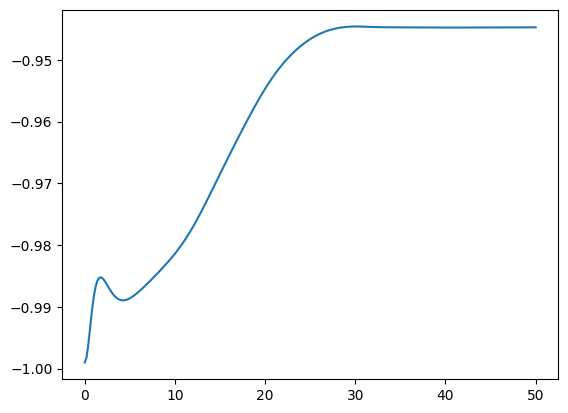

In [16]:
t,sx=dynamicspttest.expectations(op.sigma('x'),real=True)
t2,sx2=dynamicspttestswitch.expectations(op.sigma('x'),real=True)

fig,ax=plt.subplots(1)
#ax.plot(t,sx,'o')
ax.plot(t2,sx2)
#ax2=ax.twinx()
#ax2.plot(t,alpha_tramp)

In [44]:

temporesnoramp=oqupy.tempo_compute(system=system,bath=bath,
                             initial_state=rhoini,
                             start_time=0,
                             end_time=50,
                             parameters=parameters,
                             alpha_t=np.ones(num_steps))


--> TEMPO computation:
100.0%  250 of  250 [########################################] 00:04:42
Elapsed time: 282.6s


In [45]:


temporesramp=oqupy.tempo_compute(system=system,
                             bath=bath,
                             initial_state=rhoini,
                             start_time=0,
                             end_time=50,
                             alpha_t=alpha_tramp,
                             parameters=parameters)

--> TEMPO computation:
100.0%  250 of  250 [########################################] 00:03:03
Elapsed time: 183.3s


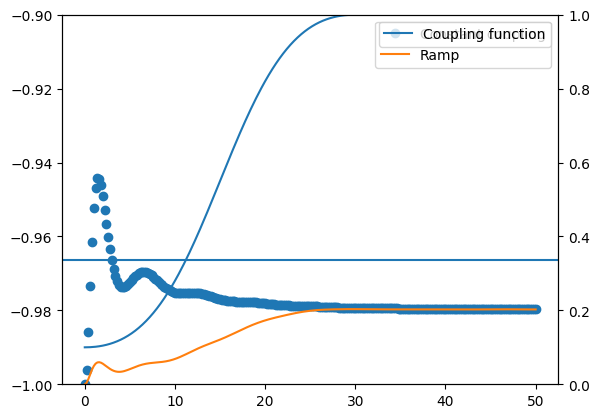

In [47]:
t,sx=temporesnoramp.expectations(op.sigma('x'))
t2,sx2=temporesramp.expectations(op.sigma('x'))
poldp=spi.quad(lambda x: correlations.spectral_density(x)/(4.0*(x**2+1.0)),0,30)[0] # heat transferred in polaron
polpred=-np.exp(-2*poldp)

fig,ax=plt.subplots(1)
ax.plot(t,sx,'o',label='Constant coupling')
ax.plot(t2,sx2,label='Ramp')
ax.legend()
ax.axhline(polpred) 
ax.set_ylim(-1,-0.9)
ax2=ax.twinx()
ax2.set_ylim(0,1)
ax2.plot(t,alpha_tramp,label='Coupling function')
ax2.legend()

In [48]:

temporesheatnoramp=oqupy.tempo_compute(system=system,bath=bathcf,
                             initial_state=rhoini,
                             start_time=0,
                             end_time=50,
                             parameters=parameters,
                             alpha_t=np.ones(num_steps))


--> TEMPO computation:
100.0%  250 of  250 [########################################] 00:04:44
Elapsed time: 284.1s


In [49]:

temporesheatramp=oqupy.tempo_compute(system=system,bath=bathcf,
                             initial_state=rhoini,
                             start_time=0,
                             end_time=50,
                             parameters=parameters,
                             alpha_t=alpha_tramp)

--> TEMPO computation:
100.0%  250 of  250 [########################################] 00:03:13
Elapsed time: 193.4s


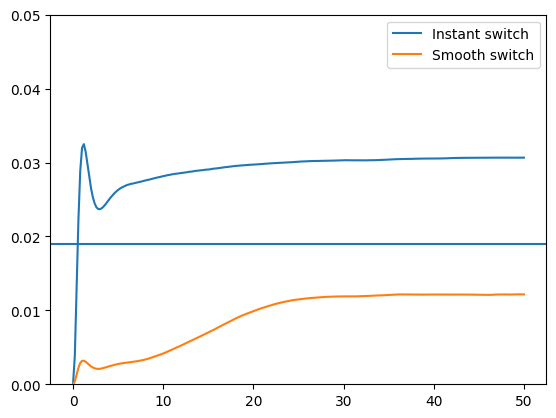

In [51]:

heats=temporesheatnoramp.states.trace(axis1=1,axis2=2).imag/u
heatsramp=temporesheatramp.states.trace(axis1=1,axis2=2).imag/u

fig,ax=plt.subplots(1)
polht=spi.quad(lambda x: correlations.spectral_density(x)*x/(4.0*(x**2+1.0)),0,10)[0] # heat transferred in polaron
ax.plot(temporesheatnoramp._times,heats,label='Instant switch')
ax.plot(temporesheatramp._times,heatsramp,label='Smooth switch')
ax.axhline(polht)
#ax.axhline(2*polht)
ax.set_ylim(0,0.05)
ax.legend()
plt.show()



In [28]:
pttempotestswitch=oqupy.pt_tempo_compute(bath=bath,
                             start_time=0,
                             end_time=50,
                             parameters=parameters,
                             alpha_t=alpha_tramp)

--> PT-TEMPO computation:
100.0%  250 of  250 [########################################] 00:00:09
Elapsed time: 9.1s


In [29]:
dynamicspttestswitch=oqupy.compute_dynamics(
    process_tensor=pttempotestswitch,        
    system=system,
    initial_state=rhoini,
    start_time=0)

--> Compute dynamics:
100.0%  250 of  250 [########################################] 00:00:00
Elapsed time: 0.1s


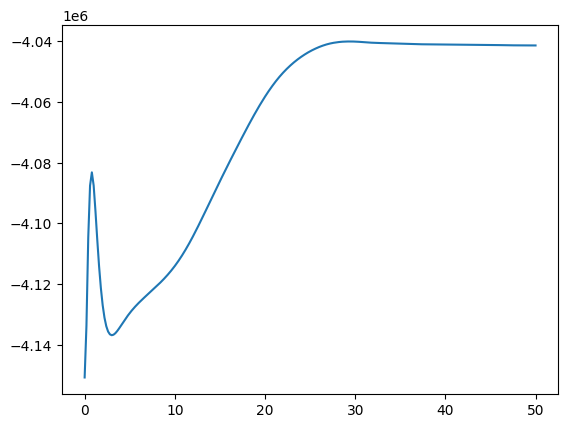

In [31]:
t,sx2=dynamicspttestswitch.expectations(op.sigma('x'),real=True)

fig,ax=plt.subplots(1)
ax.plot(t,sx2)


In [129]:
dynamicspttestswitch.states[-1].trace().imag/u

-1.0677375185866498e-07

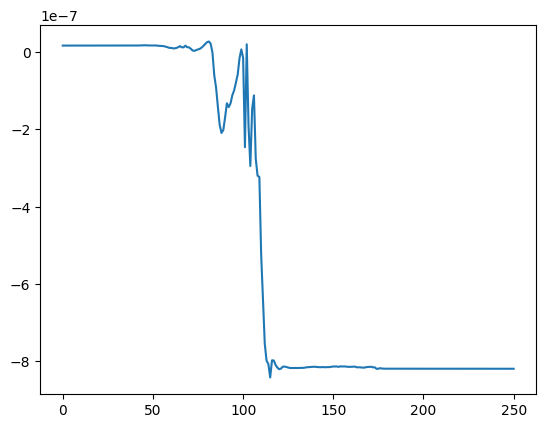

In [130]:
plt.plot(pttempoheats)